# Document Extraction Evaluation Toolkit

This notebook scores model extraction results against ground truth — **no model inference required**.

**Workflow:**
1. Each team runs their model independently and exports results as a CSV
2. Load both CSVs (ground truth + model results)
3. Score individual fields
4. Build full evaluation results
5. Generate analytics, reports, and visualizations

Both CSVs share the same format: one row per image, with columns for each extracted field.

In [1]:
# Cell 1: Imports and setup
import sys
from pathlib import Path

# Ensure project root is on the path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from common.batch_analytics import BatchAnalytics
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.config import get_document_type_fields
from common.evaluation_metrics import (
    calculate_field_accuracy_with_method,
    load_ground_truth,
)

print("Imports loaded successfully.")

Imports loaded successfully.


In [ ]:
# Cell 2: Load ground truth and model results

GROUND_TRUTH_PATH = "evaluation_data/ground_truth.csv"
MODEL_RESULTS_PATH = (
    "evaluation_data/ground_truth.csv"  # ← Replace with your team's results CSV
)

ground_truth = load_ground_truth(GROUND_TRUTH_PATH, show_sample=True)
model_results = load_ground_truth(MODEL_RESULTS_PATH, verbose=False)

# Validate: check image names in model results exist in ground truth
gt_images = set(ground_truth.keys())
mr_images = set(model_results.keys())

missing_in_gt = mr_images - gt_images
extra_in_gt = gt_images - mr_images

if missing_in_gt:
    print(
        f"⚠️  {len(missing_in_gt)} images in model results not found in ground truth: {sorted(missing_in_gt)}"
    )
if extra_in_gt:
    print(
        f"ℹ️  {len(extra_in_gt)} ground truth images not in model results (will be skipped): {sorted(extra_in_gt)}"
    )

common_images = gt_images & mr_images
print(f"\n✅ {len(common_images)} images to evaluate")

## Model Results Format

Your model results CSV must use the **same format** as `ground_truth.csv`:

- **`image_file`** column — filename matching ground truth (e.g., `bank_001.png`)
- One column per extracted field (e.g., `DOCUMENT_TYPE`, `SUPPLIER_NAME`, `TOTAL_AMOUNT`)
- **Pipe-delimited** lists for multi-value fields (e.g., `$45.00 | $30.00 | $25.00`)
- **`NOT_FOUND`** for fields the model could not extract

### Example CSV

```csv
image_file,DOCUMENT_TYPE,SUPPLIER_NAME,TOTAL_AMOUNT,LINE_ITEM_DESCRIPTIONS,LINE_ITEM_PRICES
invoice_001.png,INVOICE,Aussie Office Supplies,$4834.03,Wireless Mouse | Desk Lamp,$490.12 | $38.84
bank_001.png,BANK_STATEMENT,NOT_FOUND,NOT_FOUND,GROCERY MARKET | CAFE CENTRAL,-$78.90 | -$24.50
```

Set `MODEL_RESULTS_PATH` in Cell 2 to point to your team's exported CSV.

In [ ]:
# Cell 4: Build batch_results from model results CSV

batch_results = []
processing_times = []

for image_name in sorted(common_images):
    extracted_data = {
        k: v for k, v in model_results[image_name].items() if k != "image_file"
    }

    batch_results.append(
        {
            "image_name": image_name,
            "document_type": extracted_data.get("DOCUMENT_TYPE", "unknown").lower(),
            "processing_time": 0.0,
            "prompt_used": "external_model",
            "extracted_data": extracted_data,
        }
    )
    processing_times.append(0.0)

print(f"Built {len(batch_results)} results from model CSV.")

In [ ]:
# Cell 5: Score a single field (quick demo)

# Example: compare one field from one image
sample_image = sorted(common_images)[0]
sample_extracted = model_results[sample_image]
sample_gt = ground_truth[sample_image]

field = "TOTAL_AMOUNT"
extracted_val = sample_extracted.get(field, "NOT_FOUND")
gt_val = sample_gt.get(field, "NOT_FOUND")

print(f"Image: {sample_image}")
print(f"Field: {field}")
print(f"Extracted: {extracted_val}")
print(f"Ground Truth: {gt_val}")
print()

# Score with different methods
for method in ["order_aware_f1", "f1", "kieval"]:
    result = calculate_field_accuracy_with_method(
        extracted_val, gt_val, field, method=method, debug=False
    )
    print(f"{method:>20s}: F1={result['f1_score']:.2%}")

In [5]:
# Cell 5: Full evaluation — score all fields for all images

for result in batch_results:
    image_name = result["image_name"]
    extracted = result["extracted_data"]
    gt = ground_truth.get(image_name, {})

    doc_type = extracted.get("DOCUMENT_TYPE", "invoice").lower()
    # Map detected type to schema type
    type_map = {
        "receipt": "receipt",
        "invoice": "invoice",
        "tax invoice": "invoice",
        "bank_statement": "bank_statement",
        "bank statement": "bank_statement",
        "statement": "bank_statement",
        "travel_expense": "travel_expense",
        "travel expense": "travel_expense",
        "boarding_pass": "travel_expense",
        "airline_ticket": "travel_expense",
    }
    schema_type = type_map.get(doc_type, "invoice")
    fields = get_document_type_fields(schema_type)

    field_accuracies = {}
    for field in fields:
        ext_val = extracted.get(field, "NOT_FOUND")
        gt_val = gt.get(field, "NOT_FOUND")
        metrics = calculate_field_accuracy_with_method(
            ext_val, gt_val, field, method="order_aware_f1"
        )
        field_accuracies[field] = {"accuracy": metrics["f1_score"]}

    overall = (
        sum(d["accuracy"] for d in field_accuracies.values()) / len(field_accuracies)
        if field_accuracies
        else 0.0
    )
    matched = sum(1 for d in field_accuracies.values() if d["accuracy"] >= 0.5)

    result["evaluation"] = {
        "overall_accuracy": overall,
        "fields_extracted": len(field_accuracies),
        "fields_matched": matched,
        "total_fields": len(fields),
        "field_accuracies": field_accuracies,
    }

    print(f"{image_name}: {overall:.1%} ({matched}/{len(fields)} fields matched)")

# Overall batch accuracy
avg_acc = sum(r["evaluation"]["overall_accuracy"] for r in batch_results) / len(
    batch_results
)
print(f"\nBatch Average: {avg_acc:.1%}")

bank_001.png: 100.0% (5/5 fields matched)
bank_002.png: 100.0% (5/5 fields matched)
bank_003.png: 100.0% (5/5 fields matched)
bank_004.png: 100.0% (5/5 fields matched)
bank_005.png: 100.0% (5/5 fields matched)
bank_006.png: 100.0% (5/5 fields matched)
bank_007.png: 100.0% (5/5 fields matched)
bank_008.png: 100.0% (5/5 fields matched)
bank_009.png: 100.0% (5/5 fields matched)
bank_010.png: 100.0% (5/5 fields matched)
bank_011.png: 100.0% (5/5 fields matched)
bank_012.png: 100.0% (5/5 fields matched)
bank_013.png: 100.0% (5/5 fields matched)
bank_014.png: 100.0% (5/5 fields matched)
bank_015.png: 100.0% (5/5 fields matched)
invoice_001.png: 100.0% (14/14 fields matched)
invoice_002.png: 100.0% (14/14 fields matched)
invoice_003.png: 100.0% (14/14 fields matched)
receipt_001.png: 100.0% (14/14 fields matched)
receipt_002.png: 100.0% (14/14 fields matched)
receipt_003.png: 100.0% (14/14 fields matched)
travel_001.png: 100.0% (9/9 fields matched)
travel_002.png: 100.0% (9/9 fields matched)


In [6]:
# Cell 6: Analytics — DataFrames and CSV export

analytics = BatchAnalytics(batch_results, processing_times)

df_results = analytics.create_results_dataframe()
df_summary = analytics.create_summary_statistics(df_results)
df_doctype = analytics.create_doctype_statistics(df_results)
df_fields = analytics.create_field_statistics(df_results)

print("=== Summary Statistics ===")
display(df_summary)

print("\n=== Document Type Statistics ===")
display(df_doctype)

if df_fields is not None:
    print("\n=== Field-Level Statistics ===")
    display(df_fields)

# Optional: save to CSV
# output_dir = Path("output")
# output_dir.mkdir(exist_ok=True)
# analytics.save_all_dataframes(output_dir, "my_model_run")

=== Summary Statistics ===


,Value
Total Images,3.100000e+01
Successful Extractions,3.100000e+01
Failed Extractions,0.000000e+00
Average Accuracy (%),1.000000e+02
Median Accuracy (%),1.000000e+02
Min Accuracy (%),1.000000e+02
Max Accuracy (%),1.000000e+02
Average Processing Time (s),1.761990e-05
Total Processing Time (s),5.462170e-04
Throughput (images/min),3.405240e+06



=== Document Type Statistics ===


,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
bank_statement,100.0,100.0,0.0,100.0,100.0,0.0,0.0,15
invoice,100.0,100.0,0.0,100.0,100.0,0.0,0.0,3
receipt,100.0,100.0,0.0,100.0,100.0,0.0,0.0,3
travel_expense,100.0,100.0,0.0,100.0,100.0,0.0,0.0,10



=== Field-Level Statistics ===


,Average Accuracy (%),Min Accuracy (%),Max Accuracy (%),Std Dev (%)
DOCUMENT_TYPE,100.0,100.0,100.0,0.0
LINE_ITEM_QUANTITIES,100.0,100.0,100.0,0.0
TRAVEL_ROUTE,100.0,100.0,100.0,0.0
TRAVEL_MODE,100.0,100.0,100.0,0.0
PASSENGER_NAME,100.0,100.0,100.0,0.0
TOTAL_AMOUNT,100.0,100.0,100.0,0.0
GST_AMOUNT,100.0,100.0,100.0,0.0
IS_GST_INCLUDED,100.0,100.0,100.0,0.0
LINE_ITEM_TOTAL_PRICES,100.0,100.0,100.0,0.0
LINE_ITEM_PRICES,100.0,100.0,100.0,0.0


In [ ]:
# Cell 7: Reporting — Markdown and JSON reports
from collections import Counter

doc_types_found = dict(Counter(r["document_type"] for r in batch_results))
timestamp = "my_model_eval"

reporter = BatchReporter(batch_results, processing_times, doc_types_found, timestamp)

# Generate Markdown executive summary
md_report = reporter.generate_executive_summary(df_results, df_doctype, Path("output"))
print(md_report)

# Optional: save reports to disk
# output_dirs = {
#     "base": Path("output"),
#     "reports": Path("output/reports"),
#     "batch": Path("output/batch"),
# }
# for d in output_dirs.values():
#     d.mkdir(parents=True, exist_ok=True)
# reporter.save_all_reports(
#     output_dirs, df_results, df_summary, df_doctype,
#     model_path="your/model/path",
#     batch_config={"data_dir": str(GROUND_TRUTH_PATH)},
#     v100_config={},
# )

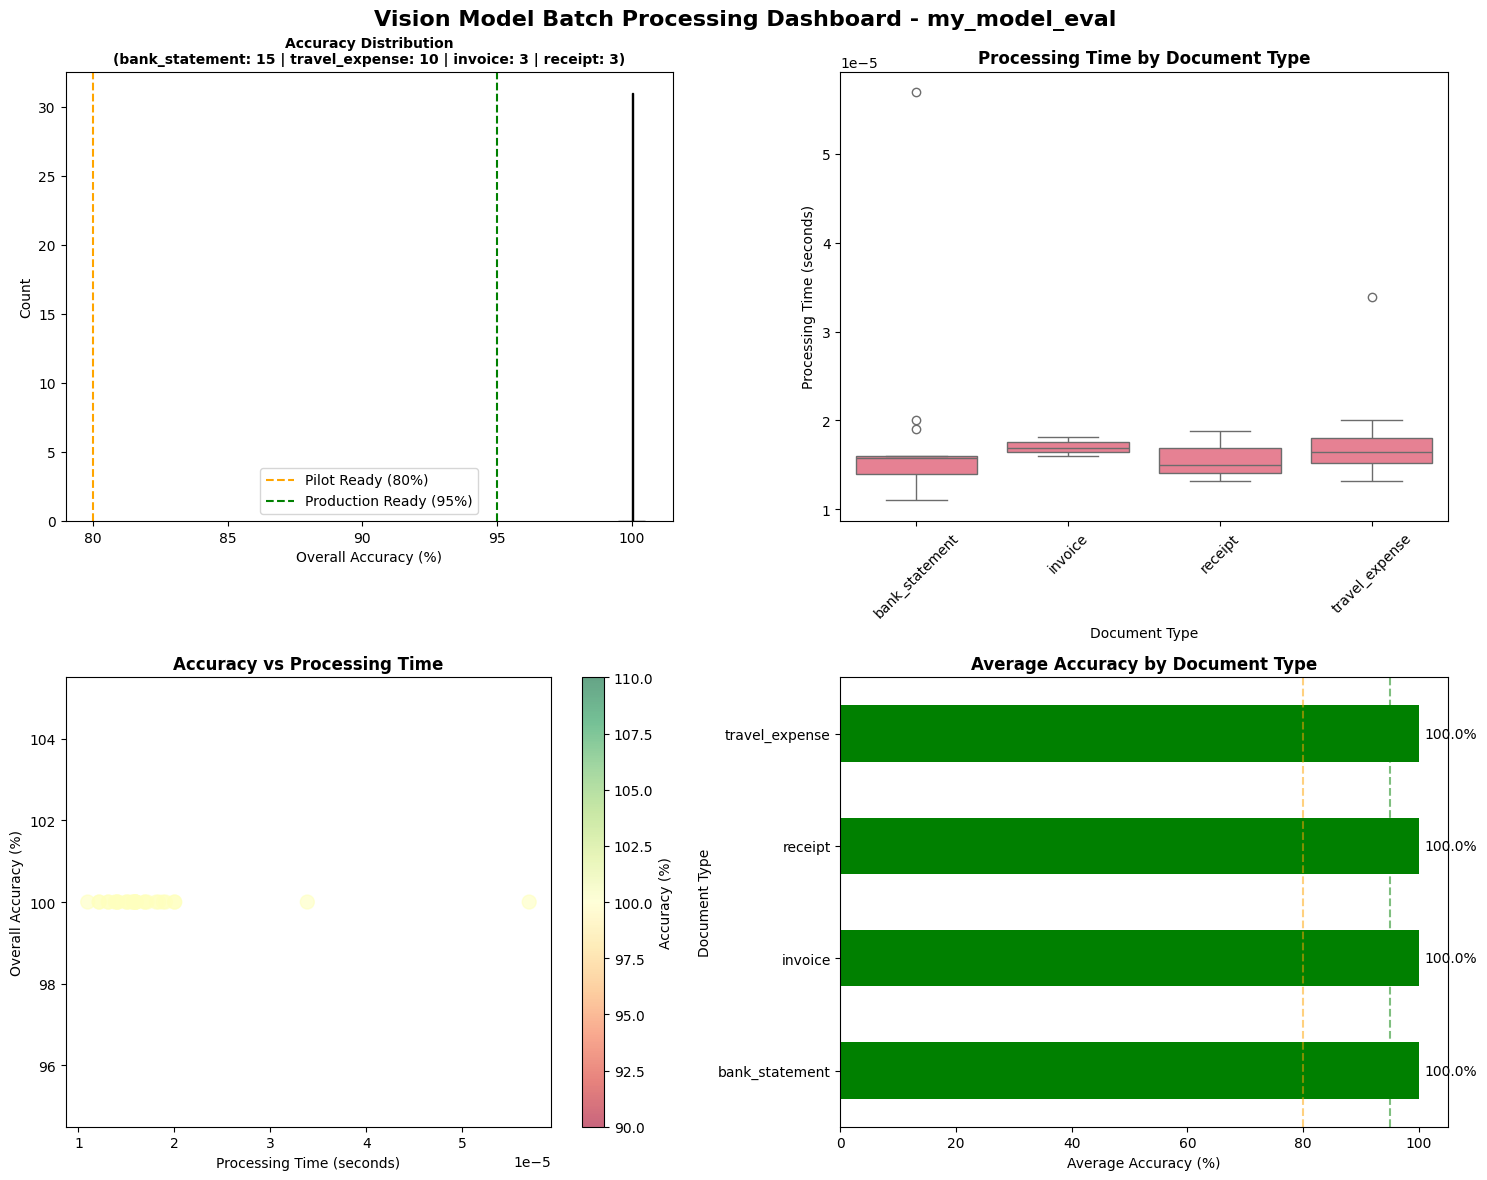

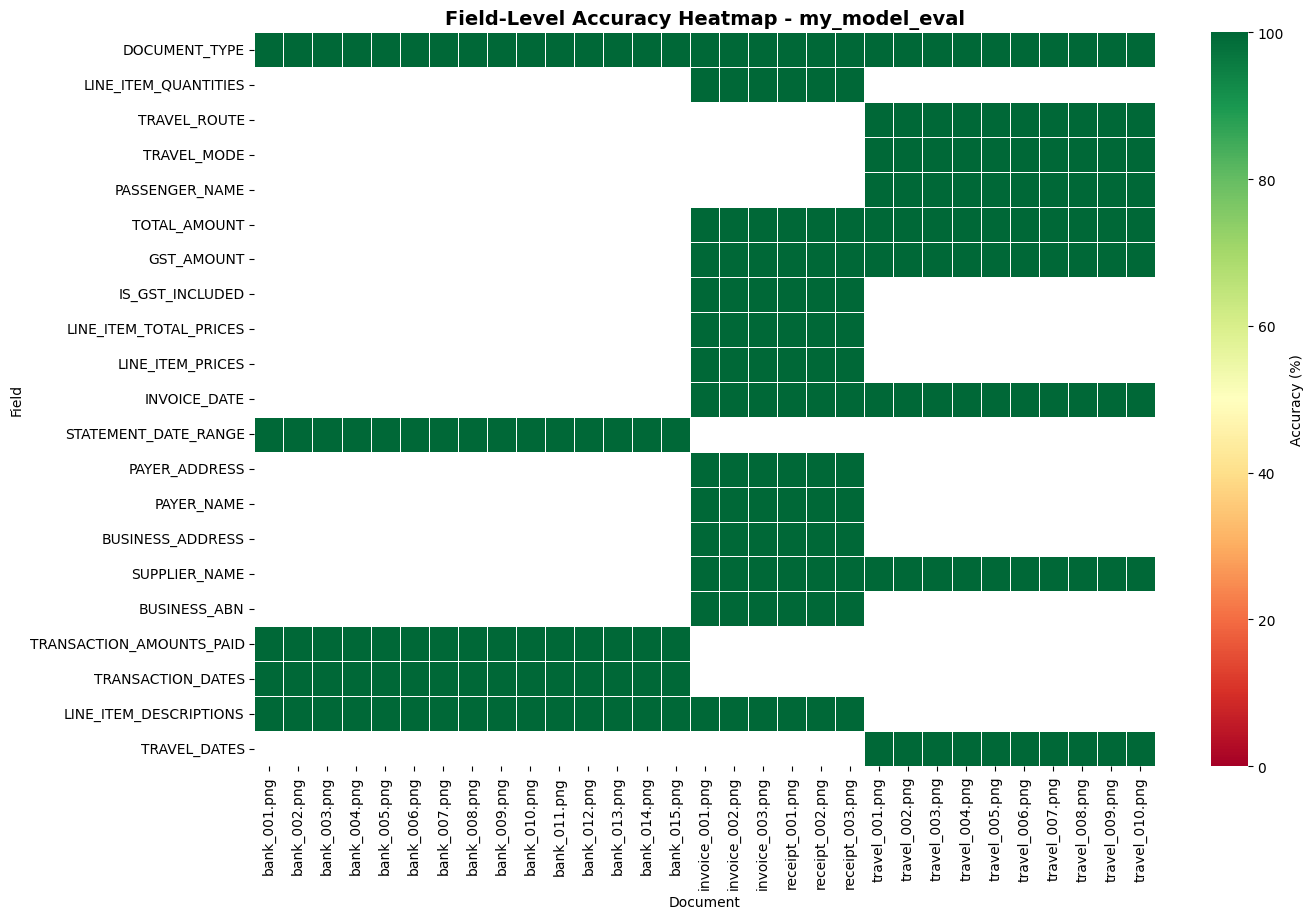

(None,
                           Average Accuracy (%)  Min Accuracy (%)  \
 DOCUMENT_TYPE                            100.0             100.0   
 LINE_ITEM_QUANTITIES                     100.0             100.0   
 TRAVEL_ROUTE                             100.0             100.0   
 TRAVEL_MODE                              100.0             100.0   
 PASSENGER_NAME                           100.0             100.0   
 TOTAL_AMOUNT                             100.0             100.0   
 GST_AMOUNT                               100.0             100.0   
 IS_GST_INCLUDED                          100.0             100.0   
 LINE_ITEM_TOTAL_PRICES                   100.0             100.0   
 LINE_ITEM_PRICES                         100.0             100.0   
 INVOICE_DATE                             100.0             100.0   
 STATEMENT_DATE_RANGE                     100.0             100.0   
 PAYER_ADDRESS                            100.0             100.0   
 PAYER_NAME                

In [8]:
# Cell 8: Visualizations — dashboard charts

visualizer = BatchVisualizer()

# Performance dashboard (2x2 grid)
visualizer.create_dashboard(
    df_results,
    df_doctype,
    timestamp,
    save_path=None,  # Set to Path("output/dashboard.png") to save
    show=True,
)

# Field-level accuracy heatmap
visualizer.create_field_heatmap(
    df_results,
    timestamp,
    save_path=None,  # Set to Path("output/heatmap.png") to save
    show=True,
)